# 定增项目综合分析报告

## 分析目标
本 Notebook 整合所有风险分析模块，生成定增项目的综合评估报告，包括：
- 项目概况与关键指标
- 收益预测分析
- 风险评估汇总
- 投资建议生成

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from utils.analysis_tools import PrivatePlacementRiskAnalyzer

# 配置中文字体
from utils.font_manager import get_font_prop
font_prop = get_font_prop()

%matplotlib inline
sns.set_style('whitegrid')

print('✅ 综合分析模块加载成功')

✅ 使用系统字体: /System/Library/Fonts/STHeiti Medium.ttc
✅ 综合分析模块加载成功


## 1. 项目基本信息

In [2]:
from utils.config_loader import load_placement_config, print_config_summary
import json

# 使用统一配置加载器获取真实市场数据
project_params, risk_params, market_data = load_placement_config('300735.SZ')
print_config_summary(project_params, risk_params, market_data)

# 发行类型评估（基于MA30判断）
ma30 = market_data.get('ma_30', 0)
issue_price = project_params['issue_price']
if issue_price < ma30:
    issue_type = "折价发行"
    discount_premium = (ma30 - issue_price) / ma30 * 100  # 折价率
else:
    issue_type = "溢价发行"
    discount_premium = (issue_price - ma30) / ma30 * 100  # 溢价率

print(f"\n{'='*50}")
print(f"发行类型评估")
print(f"{'='*50}")
print(f"MA30: {ma30:.2f} 元")
print(f"发行价: {issue_price:.2f} 元")
print(f"发行类型: {issue_type}")
if issue_type == "折价发行":
    print(f"安全边际: {discount_premium:.2f}%")
else:
    print(f"溢价率: {discount_premium:.2f}%")

# 加载光弘科技定增参数作为补充数据
with open('../300735_SZ_placement_params.json', 'r') as f:
    stock_params = json.load(f)

# 定增项目信息（使用真实市场数据）
project_info = {
    # 项目基本信息
    'company_name': '光弘科技',
    'project_name': '定增项目分析',
    'issue_date': datetime.now().strftime('%Y-%m-%d'),  # 使用当前日期
    
    # 发行参数
    'issue_price': project_params['issue_price'],      # 真实发行价
    'issue_shares': stock_params.get('issue_shares', 5000000),  # 发行数量
    'lockup_period': project_params['lockup_period'],  # 锁定期
    
    # 市场数据（使用真实市场数据）
    'current_price': market_data['current_price'],     # 真实当前价 23.88
    'ma30': ma30,                                       # MA30
    'market_cap': int(market_data['current_price'] * stock_params.get('total_shares', 2317600000)),  # 根据当前价估算
    
    # 财务数据
    'net_assets': stock_params.get('net_assets', 8000000000),        # 净资产
    'total_debt': stock_params.get('total_debt', 2000000000),        # 总债务
    'net_income': stock_params.get('net_income', 600000000),         # 净利润
    
    # 增长假设
    'revenue_growth': stock_params.get('revenue_growth', 0.25),
    'operating_margin': stock_params.get('operating_margin', 0.20),
    
    # 风险参数（使用真实市场数据）
    'volatility': market_data['volatility'],              # 真实波动率
    'drift': market_data['drift'],                        # 真实漂移率
    'beta': risk_params.get('beta', 1.2),
    'risk_free_rate': project_params['risk_free_rate'],
    
    # 发行类型评估
    'issue_type': issue_type,
    'discount_premium': discount_premium,
}

# 创建分析器
analyzer = PrivatePlacementRiskAnalyzer(
    issue_price=project_info['issue_price'],
    issue_shares=project_info['issue_shares'],
    lockup_period=project_info['lockup_period'],
    current_price=project_info['current_price'],
    risk_free_rate=project_info['risk_free_rate']
)

# 显示项目概览
print('='*70)
print('定增项目综合分析报告 - 光弘科技 (300735.SZ)')
print('='*70)
print(f"\n📊 项目基本信息")
print(f"   公司名称: {project_info['company_name']}")
print(f"   项目名称: {project_info['project_name']}")
print(f"   发行日期: {project_info['issue_date']}")
print(f"\n💰 发行参数")
print(f"   发行价格: {project_info['issue_price']} 元/股")
print(f"   发行数量: {project_info['issue_shares']:,} 股")
print(f"   融资金额: {project_info['issue_price'] * project_info['issue_shares'] / 100000000:.2f} 亿元")
print(f"   锁定期: {project_info['lockup_period']} 个月")
print(f"\n📈 市场数据")
print(f"   当前价格: {project_info['current_price']} 元/股")
print(f"   MA30: {project_info['ma30']:.2f} 元/股")
print(f"   溢价率: {(project_info['current_price']/project_info['issue_price'] - 1)*100:.2f}%")
print(f"   市值: {project_info['market_cap']/100000000:.2f} 亿元")
print(f"\n⚠️ 风险参数")
print(f"   历史波动率: {project_info['volatility']*100:.2f}%")
print(f"   Beta系数: {project_info['beta']}")
print(f"\n🏷️ 发行类型")
print(f"   {issue_type}")
if issue_type == "折价发行":
    print(f"   安全边际: {discount_premium:.2f}%")
else:
    print(f"   溢价率: {discount_premium:.2f}%")


✅ 已加载定增参数: ../300735_SZ_placement_params.json
✅ 已加载市场数据: ../300735_SZ_market_data.json
   股票: 光弘科技 (300735.SZ)
   分析日期: 20260306
   当前价格: 23.88 元
✅ 使用市场数据中的最新价格: 23.88 元
✅ 使用真实市场数据:
   波动率: 30.63% (60日)
   收益率: -18.75% (60日年化)

📊 定增分析配置

📋 项目参数:
   发行价格: 20.25 元/股
   当前价格: 23.88 元/股
   锁定期: 6 个月
   发行数量: 5,000,000 股
   融资金额: 1.01 亿元
   当前收益率: +17.95% （浮盈）

📌 发行类型判断:
   MA30: 25.31 元
   发行价: 20.25 元
   ✅ 折价发行（有安全边际）
   安全边际: 20.01%

⚠️ 风险参数:
   波动率: 30.63%
   收益率(漂移率): -18.75%
   数据来源: market_data

📈 波动率详情:
   30日: 33.96%
   60日: 30.63%
   120日: 37.13%
   180日: 36.60%

发行类型评估
MA30: 25.31 元
发行价: 20.25 元
发行类型: 折价发行
安全边际: 20.01%
定增项目综合分析报告 - 光弘科技 (300735.SZ)

📊 项目基本信息
   公司名称: 光弘科技
   项目名称: 定增项目分析
   发行日期: 2026-03-07

💰 发行参数
   发行价格: 20.245066666666666 元/股
   发行数量: 5,000,000 股
   融资金额: 1.01 亿元
   锁定期: 6 个月

📈 市场数据
   当前价格: 23.88 元/股
   MA30: 25.31 元/股
   溢价率: 17.95%
   市值: 553.44 亿元

⚠️ 风险参数
   历史波动率: 30.63%
   Beta系数: 1.2

🏷️ 发行类型
   折价发行
   安全边际: 20.01%


## 2. 收益率分析


=== 盈亏平衡分析 ===
预期收益率           盈亏平衡价           距离当前价          
---------------------------------------------
    10%          21.23元        12.47%
    15%          21.71元         9.99%
    20%          22.18元         7.68%
    25%          22.63元         5.50%
    30%          23.08元         3.45%
    40%          23.95元        -0.31%
    50%          24.80元        -3.69%


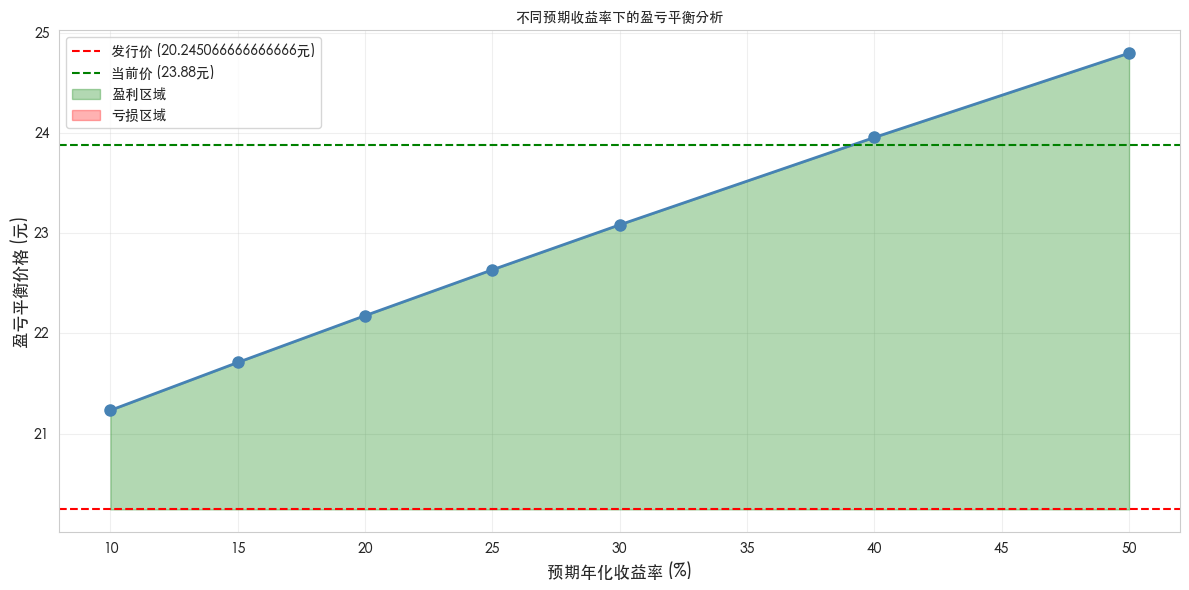

In [3]:
# 不同预期收益率下的盈亏平衡分析
target_returns = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

break_even_analysis = []
for ret in target_returns:
    be_price = analyzer.calculate_break_even_price(ret)
    distance = (project_info['current_price'] - be_price) / be_price * 100
    break_even_analysis.append({
        'target_return': ret,
        'break_even_price': be_price,
        'distance_to_current': distance
    })

df_be = pd.DataFrame(break_even_analysis)

print('\n=== 盈亏平衡分析 ===')
print(f"{'预期收益率':<15} {'盈亏平衡价':<15} {'距离当前价':<15}")
print('-'*45)
for _, row in df_be.iterrows():
    print(f"{row['target_return']*100:>6.0f}%       {row['break_even_price']:>8.2f}元      {row['distance_to_current']:>7.2f}%")

# 可视化
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_be['target_return']*100, df_be['break_even_price'], 'o-', linewidth=2, markersize=8, color='steelblue')
ax.axhline(y=project_info['issue_price'], color='r', linestyle='--', label=f"发行价 ({project_info['issue_price']}元)")
ax.axhline(y=project_info['current_price'], color='g', linestyle='--', label=f"当前价 ({project_info['current_price']}元)")
ax.fill_between(df_be['target_return']*100, df_be['break_even_price'], project_info['issue_price'], 
                where=(df_be['break_even_price'] >= project_info['issue_price']), 
                alpha=0.3, color='green', label='盈利区域')
ax.fill_between(df_be['target_return']*100, df_be['break_even_price'], project_info['issue_price'], 
                where=(df_be['break_even_price'] < project_info['issue_price']), 
                alpha=0.3, color='red', label='亏损区域')
ax.set_xlabel('预期年化收益率 (%)', fontsize=12, fontproperties=font_prop)
ax.set_ylabel('盈亏平衡价格 (元)', fontsize=12, fontproperties=font_prop)
ax.set_title('不同预期收益率下的盈亏平衡分析', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax.legend(prop=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 风险评估汇总

In [4]:
# 计算各项风险指标
# 1. 波动率风险
volatility_risk = project_info['volatility']

# 2. 盈亏平衡距离
be_price_20 = analyzer.calculate_break_even_price(0.20)
distance_to_be = (analyzer.current_price - be_price_20) / analyzer.current_price

# 3. 计算盈利概率（蒙特卡洛）
print('运行蒙特卡洛模拟以评估盈利概率...')
sim_results = analyzer.monte_carlo_simulation(
    n_simulations=5000,
    volatility=project_info['volatility'],
    drift=project_info['drift'],
    seed=42
)

lockup_days = project_info['lockup_period'] * 30
final_prices = sim_results.iloc[:, lockup_days].values
returns = (final_prices - project_info['issue_price']) / project_info['issue_price']
profit_prob = (returns > 0).sum() / len(returns)

# 4. VaR 计算（简化）
var_95 = abs(np.percentile(returns, 5))
var_99 = abs(np.percentile(returns, 1))

# 5. 最大回撤估算（基于波动率）
estimated_max_dd = volatility_risk * 2  # 简化估算

# 风险指标汇总
risk_metrics = {
    '盈利概率': profit_prob,
    '破发概率': 1 - profit_prob,
    'VaR_95%': var_95,
    'VaR_99%': var_99,
    '预估最大回撤': estimated_max_dd,
    '波动率': volatility_risk,
    '距离盈亏平衡': distance_to_be
}

print('\n=== 风险指标汇总 ===')
print(f"盈利概率: {profit_prob*100:.1f}%")
print(f"破发概率: {(1-profit_prob)*100:.1f}%")
print(f"95% VaR: {var_95*100:.1f}%")
print(f"99% VaR: {var_99*100:.1f}%")
print(f"预估最大回撤: {estimated_max_dd*100:.1f}%")
print(f"波动率: {volatility_risk*100:.0f}%")

运行蒙特卡洛模拟以评估盈利概率...

=== 风险指标汇总 ===
盈利概率: 49.0%
破发概率: 51.0%
95% VaR: 35.0%
99% VaR: 46.3%
预估最大回撤: 61.3%
波动率: 31%


## 4. 综合风险评分

In [5]:
# 综合风险评分系统
risk_score = 0
risk_factors = []

# 1. 盈利概率评分 (0-30分)
if profit_prob >= 0.7:
    prob_score = 30
    risk_factors.append("✅ 盈利概率高 (≥70%)")
elif profit_prob >= 0.5:
    prob_score = 20
    risk_factors.append("⚠️ 盈利概率中等 (50%-70%)")
else:
    prob_score = 10
    risk_factors.append("❌ 盈利概率低 (<50%)")

risk_score += prob_score

# 2. 折价保护评分 (0-20分)
discount = (analyzer.current_price / analyzer.issue_price - 1)
if discount <= -0.2:  # 折价≥20%
    discount_score = 20
    risk_factors.append(f"✅ 折价保护充足 ({discount*100:.1f}%)")
elif discount <= -0.1:
    discount_score = 15
    risk_factors.append(f"⚠️ 折价保护一般 ({discount*100:.1f}%)")
else:
    discount_score = 5
    risk_factors.append(f"❌ 折价保护不足 ({discount*100:.1f}%)")

risk_score += discount_score

# 3. 锁定期评分 (0-20分)
if project_info['lockup_period'] <= 6:
    lockup_score = 20
    risk_factors.append(f"✅ 锁定期短 ({project_info['lockup_period']}个月)")
elif project_info['lockup_period'] <= 12:
    lockup_score = 15
    risk_factors.append(f"⚠️ 锁定期中等 ({project_info['lockup_period']}个月)")
else:
    lockup_score = 5
    risk_factors.append(f"❌ 锁定期长 ({project_info['lockup_period']}个月)")

risk_score += lockup_score

# 4. 波动率评分 (0-15分)
if volatility_risk <= 0.25:
    vol_score = 15
    risk_factors.append(f"✅ 波动率低 ({volatility_risk*100:.0f}%)")
elif volatility_risk <= 0.40:
    vol_score = 10
    risk_factors.append(f"⚠️ 波动率中等 ({volatility_risk*100:.0f}%)")
else:
    vol_score = 5
    risk_factors.append(f"❌ 波动率高 ({volatility_risk*100:.0f}%)")

risk_score += vol_score

# 5. VaR评分 (0-15分)
if var_95 <= 0.15:
    var_score = 15
    risk_factors.append(f"✅ VaR可控 ({var_95*100:.1f}%)")
elif var_95 <= 0.25:
    var_score = 10
    risk_factors.append(f"⚠️ VaR较高 ({var_95*100:.1f}%)")
else:
    var_score = 3
    risk_factors.append(f"❌ VaR过高 ({var_95*100:.1f}%)")

risk_score += var_score

# 输出风险因素
print('\n=== 风险因素分析 ===')
for factor in risk_factors:
    print(factor)

print(f"\n总风险评分: {risk_score}/100 分")


=== 风险因素分析 ===
❌ 盈利概率低 (<50%)
❌ 折价保护不足 (18.0%)
✅ 锁定期短 (6个月)
⚠️ 波动率中等 (31%)
❌ VaR过高 (35.0%)

总风险评分: 48/100 分


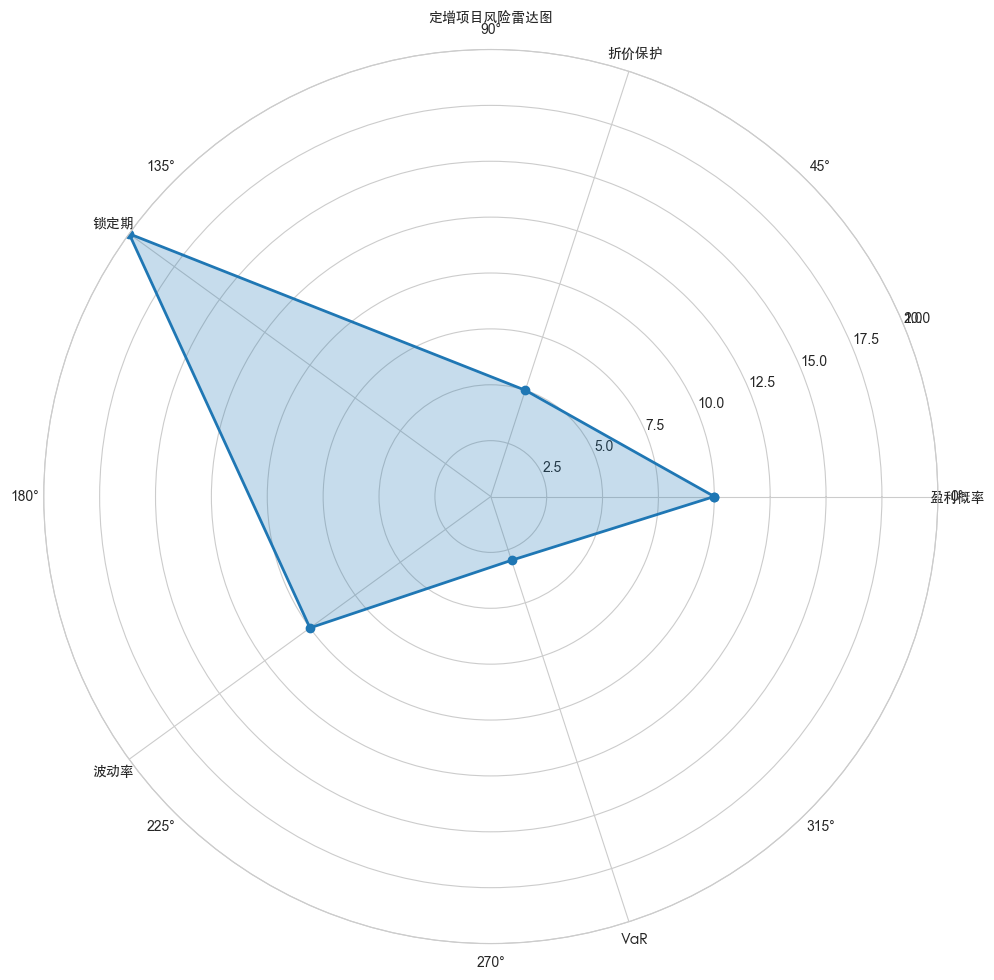

In [6]:
# 雷达图展示风险评分
categories = ['盈利概率', '折价保护', '锁定期', '波动率', 'VaR']
scores = [prob_score, discount_score, lockup_score, vol_score, var_score]

# 闭合雷达图：将第一个元素添加到末尾
angles_plot = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles_plot += angles_plot[:1]  # 闭合角度
scores_plot = scores + scores[:1]  # 闭合分数

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

ax = plt.subplot(111, projection='polar')
ax.plot(angles_plot, scores_plot, 'o-', linewidth=2, label='风险评分')
ax.fill(angles_plot, scores_plot, alpha=0.25)
ax.set_xticks(angles_plot[:-1])
ax.set_xticklabels(categories, fontproperties=font_prop)
ax.set_ylim(0, 20)
ax.set_title('定增项目风险雷达图', fontsize=14, fontweight='bold', pad=20, fontproperties=font_prop)
ax.grid(True)

plt.tight_layout()
plt.show()

## 5. 投资建议生成

In [7]:
# 根据风险评分生成投资建议
print('\n' + '='*70)
print('投资建议')
print('='*70)

if risk_score >= 80:
    recommendation = "🟢 建议投资"
    detail = "项目风险收益比良好，各项风险指标可控，建议积极参与。"
    action_items = [
        "1. 可以按计划参与定增",
        "2. 建议关注锁定期内的市场动态",
        "3. 可考虑适当杠杆"
    ]
elif risk_score >= 60:
    recommendation = "🟡 谨慎投资"
    detail = "项目存在一定风险，建议谨慎评估后决定。"
    action_items = [
        "1. 深入调研项目基本面",
        "2. 评估自身风险承受能力",
        "3. 考虑分批参与"
    ]
else:
    recommendation = "🔴 不建议投资"
    detail = "项目风险过高，建议观望或寻找其他机会。"
    action_items = [
        "1. 暂不建议参与",
        "2. 等待更好的入场时机",
        "3. 考虑其他投资标的"
    ]

print(f"\n{recommendation}")
print(f"\n{detail}")
print(f"\n建议行动:")
for item in action_items:
    print(f"  {item}")

print(f"\n核心指标汇总:")
print(f"  风险评分: {risk_score}/100")
print(f"  盈利概率: {profit_prob*100:.1f}%")
print(f"  发行折价: {discount*100:.1f}%")
print(f"  锁定期: {project_info['lockup_period']}个月")
print(f"  波动率: {volatility_risk*100:.0f}%")


投资建议

🔴 不建议投资

项目风险过高，建议观望或寻找其他机会。

建议行动:
  1. 暂不建议参与
  2. 等待更好的入场时机
  3. 考虑其他投资标的

核心指标汇总:
  风险评分: 48/100
  盈利概率: 49.0%
  发行折价: 18.0%
  锁定期: 6个月
  波动率: 31%


## 6. 生成分析报告（导出）

In [8]:
# 生成报告摘要（包含发行类型评估）

# 构建基础报告
base_report = f"""
============================================================
                定增项目综合分析报告
============================================================

一、项目概况
-----------------------------------------------------------
公司名称: {project_info['company_name']}
项目名称: {project_info['project_name']}
发行日期: {project_info['issue_date']}
当前日期: {datetime.now().strftime('%Y-%m-%d')}

二、发行参数
-----------------------------------------------------------
发行价格: {project_info['issue_price']:.2f} 元/股
发行数量: {project_info['issue_shares']:,} 股
融资金额: {project_info['issue_price'] * project_info['issue_shares'] / 100000000:.2f} 亿元
锁定期: {project_info['lockup_period']} 个月

三、发行类型评估
-----------------------------------------------------------
MA30价格: {project_info['ma30']:.2f} 元/股
发行类型: {project_info['issue_type']}
"""

# 添加发行类型详情
if project_info['issue_type'] == "折价发行":
    base_report += f"安全边际: {project_info['discount_premium']:.2f}%\n"
else:
    base_report += f"溢价率: {project_info['discount_premium']:.2f}%\n"

# 继续添加市场状况
base_report += f"""

四、市场状况
-----------------------------------------------------------
当前价格: {project_info['current_price']:.2f} 元/股
发行折价: {(project_info['current_price']/project_info['issue_price'] - 1)*100:.2f}%
市值: {project_info['market_cap']/100000000:.2f} 亿元

五、收益预测
-----------------------------------------------------------
20%年化收益率盈亏平衡价: {analyzer.calculate_break_even_price(0.20):.2f} 元/股
当前价距盈亏平衡: {distance_to_be*100:.2f}%

六、风险评估
-----------------------------------------------------------
盈利概率: {profit_prob*100:.1f}%
破发概率: {(1-profit_prob)*100:.1f}%
95% VaR: {var_95*100:.1f}%
99% VaR: {var_99*100:.1f}%
预估最大回撤: {estimated_max_dd*100:.1f}%
波动率: {volatility_risk*100:.0f}%

七、综合评分
-----------------------------------------------------------
总风险评分: {risk_score}/100

八、投资建议
-----------------------------------------------------------
{recommendation}
{detail}

============================================================
报告生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
============================================================
"""

print(base_report)



                定增项目综合分析报告

一、项目概况
-----------------------------------------------------------
公司名称: 光弘科技
项目名称: 定增项目分析
发行日期: 2026-03-07
当前日期: 2026-03-07

二、发行参数
-----------------------------------------------------------
发行价格: 20.25 元/股
发行数量: 5,000,000 股
融资金额: 1.01 亿元
锁定期: 6 个月

三、发行类型评估
-----------------------------------------------------------
MA30价格: 25.31 元/股
发行类型: 折价发行
安全边际: 20.01%


四、市场状况
-----------------------------------------------------------
当前价格: 23.88 元/股
发行折价: 17.95%
市值: 553.44 亿元

五、收益预测
-----------------------------------------------------------
20%年化收益率盈亏平衡价: 22.18 元/股
当前价距盈亏平衡: 7.13%

六、风险评估
-----------------------------------------------------------
盈利概率: 49.0%
破发概率: 51.0%
95% VaR: 35.0%
99% VaR: 46.3%
预估最大回撤: 61.3%
波动率: 31%

七、综合评分
-----------------------------------------------------------
总风险评分: 48/100

八、投资建议
-----------------------------------------------------------
🔴 不建议投资
项目风险过高，建议观望或寻找其他机会。

报告生成时间: 2026-03-07 12:53:07



In [11]:
# 保存报告到文件（可选）
with open('../report.txt', 'w', encoding='utf-8') as f:
    f.write(base_report)
print('\n报告已保存到 ../report.txt')


报告已保存到 ../report.txt
